# Perform manual annotation of the subset of cells to evaluate QC performance on dataset

In [ ]:
import itertools
import re
from pathlib import Path

import ipywidgets as widgets
import numpy as np
import pandas as pd
from cytodataframe import CytoDataFrame
from IPython.display import clear_output, display
from plotnine import (
    aes,
    element_text,
    facet_grid,
    facet_wrap,
    geom_hline,
    geom_point,
    geom_text,
    geom_tile,
    ggplot,
    labs,
    scale_fill_gradient,
    theme,
    theme_bw,
)
from plotnine.options import set_option
from sklearn.metrics import cohen_kappa_score, confusion_matrix


## Helper functions to create manual annotation method

In [2]:
def save_annotation(label: str) -> None:
    """
    Save the annotation for the current cell to the annotations DataFrame.

    Args:
        label (str): The annotation label for the current cell
            (e.g., "good", "bad", "unsure").
    """
    global annotations_df  # noqa: PLW0603

    row = pending_df.iloc[current_position]
    new_annotation = pd.DataFrame(
        {
            "sample_row_id": [int(row["sample_row_id"])],
            "manual_segmentation_label": [label],
            "manual_segmentation_is_bad": [label == "bad"],
        }
    )

    annotations_df = (
        pd.concat([annotations_df, new_annotation], ignore_index=True)
        .drop_duplicates("sample_row_id", keep="last")
        .sort_values("sample_row_id")
        .reset_index(drop=True)
    )
    annotations_df.to_parquet(annotation_path, index=False)


def print_cytodataframe_debug(row_df: pd.DataFrame) -> None:
    """
    Print debug for CytoDataFrame in case of issue with rendering crops.

    Args:
        row_df (pd.DataFrame): The DataFrame row being visualized in the CytoDataFrame.
    """
    print("CytoDataFrame debug")
    print("sample_row_id:", int(row_df["sample_row_id"].iloc[0]))
    print("outline_context_dir exists:", outline_context_dir.exists())
    print("outline_context_dir:", outline_context_dir)

    for filename_column, path_column in zip(image_filename_columns, image_path_columns):
        filename = str(row_df[filename_column].iloc[0])
        image_path = Path(str(row_df[path_column].iloc[0]), filename)
        print(f"{filename_column}: {image_path} | exists={image_path.exists()}")

        matching_outline_patterns = [
            outline_pattern
            for outline_pattern, image_pattern in outline_to_orig_mapping.items()
            if re.search(image_pattern, filename)
        ]
        print(f"matched outline patterns for {filename_column}:")
        for outline_pattern in matching_outline_patterns[:3]:
            outline_matches = [
                path.name
                for path in outline_context_dir.rglob("*")
                if re.search(outline_pattern, path.name)
            ]
            print(f"  {outline_pattern} -> {outline_matches[:3]}")

    if bounding_box_columns:
        print("bounding_box:", row_df[bounding_box_columns].iloc[0].to_dict())
    if center_xy_columns:
        print("center_xy:", row_df[center_xy_columns].iloc[0].to_dict())


def show_current_cell() -> None:
    """
    Display the current cell for annotation in the CytoDataFrame,
    along with progress information.
    If there are no pending cells left to annotate, display a completion message.
    """
    with output:
        clear_output(wait=True)

        if len(pending_df) == 0 or current_position >= len(pending_df):
            progress.value = "<b>All sampled cells have been annotated.</b>"
            print("All sampled cells have been annotated.")
            return

        progress.value = (
            f"<b>Current:</b> {current_position + 1} of {len(pending_df)} pending "
            f"| <b>Saved total:</b> {len(annotations_df)}"
        )
        row_df = pending_df.iloc[[current_position]].copy()
        if DEBUG_CYTODATAFRAME:
            print_cytodataframe_debug(row_df)

        row_cdf = CytoDataFrame(
            data=row_df[display_columns],
            data_image_paths=row_df[image_path_columns] if image_path_columns else None,
            data_bounding_box=(
                row_df[bounding_box_columns] if bounding_box_columns else None
            ),
            compartment_center_xy=(
                row_df[center_xy_columns] if center_xy_columns else False
            ),
            data_outline_context_dir=outline_context_dir,
            segmentation_file_regex=outline_to_orig_mapping,
            display_options={"brightness": 1},
        )
        if DEBUG_CYTODATAFRAME:
            row_cdf._enbable_debug_mode()
        display(row_cdf)


def annotate_and_advance(label: str) -> None:
    """
    Save the annotation for the current cell and advance to the next cell.

    Args:
        label (str): The annotation label for the current cell
            (e.g., "good", "bad", "unsure").
    """
    global current_position  # noqa: PLW0603

    if len(pending_df) == 0:
        show_current_cell()
        return

    save_annotation(label)
    current_position += 1

    show_current_cell()

## Load in stratified QC sample

In [3]:
# set plate that was used for the stratified sample
plate_id = "BR00145816"

# Set path to the stratified sample
sample_path = Path("./data/stratified_qc_sample.parquet")

# Load the stratified sample for manual annotation
qc_sample_df = pd.read_parquet(sample_path)
print("Stratified sample loaded from:", sample_path)
print(qc_sample_df.shape)

preview_columns = [
    column
    for column in [
        "Metadata_cell_line",
        "Metadata_condition",
        "Metadata_Plate",
        "Metadata_Well",
        "Image_Metadata_Row",
        "Image_Metadata_Col",
    ]
    if column in qc_sample_df.columns
]
qc_sample_df[preview_columns].head()

Stratified sample loaded from: data/stratified_qc_sample.parquet
(400, 26)


,Metadata_cell_line,Metadata_condition,Metadata_Plate,Metadata_Well,Image_Metadata_Row,Image_Metadata_Col
0,CHLA-10,synthemax_PFA,BR00145816,C12,3,12
1,CHLA-10,synthemax_PFA,BR00145816,B04,2,4
2,CHLA-10,synthemax_PFA,BR00145816,C07,3,7
3,CHLA-10,synthemax_PFA,BR00145816,B12,2,12
4,CHLA-10,synthemax_PFA,BR00145816,C12,3,12


## Manually annotate segmentation quality

The annotation widget below is intentionally blinded to the coSMicQC `failed_qc` result. It saves every button click to disk immediately and only serves cells that have not already been annotated.

In [4]:
# Save manual annotations separately from the stratified sample
name_of_annotator = "test"  # change to your name or initials
annotation_path = Path(
    f"./data/manual_segmentation_annotations_{name_of_annotator}.parquet"
)
annotation_path.parent.mkdir(parents=True, exist_ok=True)

# Stable identifier for each sampled cell. This lets us resume safely even after
# shuffling and lets us merge with failed_qc only after manual annotation is done.
annotation_df = qc_sample_df.reset_index(names="sample_row_id").copy()

# Shuffle once for blinded review. Existing annotations are matched by sample_row_id,
# so resuming the notebook does not create duplicate work.
annotation_df = annotation_df.sample(frac=1, random_state=42).reset_index(drop=True)

if annotation_path.exists():
    annotations_df = pd.read_parquet(annotation_path)

    required_cols = {
        "sample_row_id",
        "manual_segmentation_label",
        "manual_segmentation_is_bad",
    }

    missing = required_cols - set(annotations_df.columns)

    if missing:
        raise ValueError(
            f"Annotation file is not valid. Missing columns: {missing}. "
            f"Likely wrong or overwritten file at {annotation_path}."
        )
else:
    annotations_df = pd.DataFrame(
        columns=[
            "sample_row_id",
            "manual_segmentation_label",
            "manual_segmentation_is_bad",
        ]
    )

annotations_df = annotations_df.drop_duplicates("sample_row_id", keep="last")
annotated_ids = set(annotations_df["sample_row_id"].astype(int))
pending_df = annotation_df.loc[
    ~annotation_df["sample_row_id"].astype(int).isin(annotated_ids)
].reset_index(drop=True)

print(f"Saved annotation file: {annotation_path}")
print(f"Already annotated: {len(annotations_df)}")
print(f"Remaining cells: {len(pending_df)}")

Saved annotation file: data/manual_segmentation_annotations_test.parquet
Already annotated: 400
Remaining cells: 0


In [5]:
# Create an outline-to-original-image regex mapping for CytoDataFrame.
# DNA images should display nuclei outlines; AGP images should display cell outlines.
# The regex values are matched against each Image_FileName_* value shown by CytoDataFrame.
outline_to_orig_mapping = {}

for record in pending_df[
    [
        "Metadata_Plate",
        "Metadata_Well",
        "Image_Metadata_Site",
        "Image_Metadata_Row",
        "Image_Metadata_Col",
    ]
].to_dict(orient="records"):
    image_prefix = (
        rf"r{int(record['Image_Metadata_Row']):02d}"
        rf"c{int(record['Image_Metadata_Col']):02d}"
        rf"f{int(record['Image_Metadata_Site']):02d}"
    )

    outline_to_orig_mapping[
        rf"NucleiOutlines_{record['Metadata_Plate']}_{record['Metadata_Well']}_{record['Image_Metadata_Site']}\.tiff"
    ] = rf"{image_prefix}p\d{{2}}-ch5sk\d+fk\d+fl\d+\.tiff"

    outline_to_orig_mapping[
        rf"CellsOutlines_{record['Metadata_Plate']}_{record['Metadata_Well']}_{record['Image_Metadata_Site']}\.tiff"
    ] = rf"{image_prefix}p\d{{2}}-ch3sk\d+fk\d+fl\d+\.tiff"

list(outline_to_orig_mapping.items())[:2]

[]

In [6]:
# CytoDataFrame display setup. The rendered table should only contain image
# filename columns. Image paths, bounding boxes, center coordinates, and outline
# mappings are passed to CytoDataFrame as rendering metadata.
DEBUG_CYTODATAFRAME = False

outline_context_dir = Path(
    f"/media/18tbdrive/1.Github_Repositories/pediatric_cancer_atlas_profiling/2.feature_extraction/sqlite_outputs/Round_2_data/{plate_id}"
).resolve()

image_filename_columns = [
    column
    for column in ["Image_FileName_OrigDNA", "Image_FileName_OrigAGP"]
    if column in pending_df.columns
]
image_path_columns = [
    column
    for column in [
        filename_column.replace("FileName", "PathName")
        for filename_column in image_filename_columns
    ]
    if column in pending_df.columns
]
bounding_box_columns = [
    column
    for column in [
        "Cells_AreaShape_BoundingBoxMinimum_X",
        "Cells_AreaShape_BoundingBoxMinimum_Y",
        "Cells_AreaShape_BoundingBoxMaximum_X",
        "Cells_AreaShape_BoundingBoxMaximum_Y",
    ]
    if column in pending_df.columns
]
center_xy_columns = [
    column
    for column in [
        "Metadata_Cells_Location_Center_X",
        "Metadata_Cells_Location_Center_Y",
    ]
    if column in pending_df.columns
]

# Only these columns will be visible in the CytoDataFrame display.
display_columns = image_filename_columns

required_render_columns = (
    image_filename_columns
    + image_path_columns
    + bounding_box_columns
    + center_xy_columns
)
missing_render_columns = [
    column for column in required_render_columns if column not in pending_df.columns
]

print("Visible CytoDataFrame columns:", display_columns)
print("Image path metadata columns:", image_path_columns)
print("Bounding box metadata columns:", bounding_box_columns)
print("Center XY metadata columns:", center_xy_columns)
print("Outline context exists:", outline_context_dir.exists(), outline_context_dir)
print("Outline regex mappings:", len(outline_to_orig_mapping))
if missing_render_columns:
    print("Missing render columns:", missing_render_columns)

Visible CytoDataFrame columns: ['Image_FileName_OrigDNA', 'Image_FileName_OrigAGP']
Image path metadata columns: ['Image_PathName_OrigDNA', 'Image_PathName_OrigAGP']
Bounding box metadata columns: ['Cells_AreaShape_BoundingBoxMinimum_X', 'Cells_AreaShape_BoundingBoxMinimum_Y', 'Cells_AreaShape_BoundingBoxMaximum_X', 'Cells_AreaShape_BoundingBoxMaximum_Y']
Center XY metadata columns: ['Metadata_Cells_Location_Center_X', 'Metadata_Cells_Location_Center_Y']
Outline context exists: True /media/18tbdrive/1.Github_Repositories/pediatric_cancer_atlas_profiling/2.feature_extraction/sqlite_outputs/Round_2_data/BR00145816
Outline regex mappings: 0


### Fix path name root path to `bandicoot` path

In [7]:
# Map original image paths to bandicoot mount paths for CytoDataFrame rendering
old_root = Path("/media/18tbdrive/ALSF_pilot_data/Round_2_data")

# Find the bandicoot mount anywhere under the user's home directory
bandicoot_root = next(p for p in Path.home().rglob("bandicoot") if p.is_dir())

# Set new root to find images in a common place
new_root = Path.home() / "mnt" / "bandicoot" / "Mike_manual_annotation_ALSF" / "images"

pending_df[image_path_columns] = pending_df[image_path_columns].apply(
    lambda col: col.map(
        lambda p: (str(new_root / Path(p).relative_to(old_root)) if pd.notna(p) else p)
    )
)

# Confirm it worked
pending_df[image_path_columns].head()

,Image_PathName_OrigDNA,Image_PathName_OrigAGP


In [8]:
# --- Set up interactive widgets for manual annotation and navigation ---
# Assign current position after loading existing annotations
current_position = 0
# Set output and progress display widgets
output = widgets.Output()
progress = widgets.HTML()

# Set up annotation buttons and their callbacks
good_button = widgets.Button(
    description="Good segmentation",
    button_style="success",
    icon="check",
)
bad_button = widgets.Button(
    description="Bad segmentation",
    button_style="danger",
    icon="times",
)
unsure_button = widgets.Button(
    description="Unsure / skip",
    button_style="warning",
    icon="question",
)

# Connect button clicks to annotation and navigation logic
good_button.on_click(lambda _: annotate_and_advance("good"))
bad_button.on_click(lambda _: annotate_and_advance("bad"))
unsure_button.on_click(lambda _: annotate_and_advance("unsure"))

# Initial display of progress and controls and complete manual annotation interface
display(progress)
display(widgets.HBox([good_button, bad_button, unsure_button]))
display(output)
show_current_cell()

HTML(value='')

Output()

## Evaluate against coSMicQC labels across both manual annotations

In [9]:
# Set path to manual annotation files from experts
annotation_paths = list(
    Path("./data").rglob("*manual_segmentation_annotations*.parquet")
)

if not annotation_paths:
    raise ValueError("No annotation parquet files found.")

# Concat annotations + add annotator from filename
annotations_df = pd.concat(
    [
        pd.read_parquet(p).assign(
            annotator=p.stem.split("manual_segmentation_annotations")[-1]
        )
        for p in annotation_paths
    ],
    ignore_index=True,
)

# Blind the annotators
annotations_df["annotator"] = annotations_df["annotator"].str.lstrip("_")

annotator_map = {
    annotator: f"Annotator {i + 1}"
    for i, annotator in enumerate(sorted(annotations_df["annotator"].unique()))
}

annotations_df["annotator"] = annotations_df["annotator"].map(annotator_map)


annotations_df.head()

,sample_row_id,manual_segmentation_label,manual_segmentation_is_bad,annotator
0,0,good,False,Annotator 2
1,1,bad,True,Annotator 2
2,2,good,False,Annotator 2
3,3,bad,True,Annotator 2
4,4,bad,True,Annotator 2


In [10]:
manual_eval_df = annotation_df.merge(
    annotations_df,
    on="sample_row_id",
    how="inner",
)

# keep only valid labels
manual_eval_df = manual_eval_df.loc[
    manual_eval_df["manual_segmentation_label"].isin(["good", "bad"])
].copy()

# encode manual labels
manual_eval_df["manual_segmentation_is_bad"] = (
    manual_eval_df["manual_segmentation_label"] == "bad"
).astype(int)

manual_eval_df["failed_qc"] = manual_eval_df["failed_qc"].astype(int)

# -----------------------------
# confusion matrix (split by annotator)
# -----------------------------
confusion_df = (
    manual_eval_df
    .groupby(["annotator", "failed_qc", "manual_segmentation_is_bad"])
    .size()
    .reset_index(name="count")
)

# -----------------------------
# save evaluation dataset
# -----------------------------
manual_eval_df.to_parquet(
    "./data/manual_segmentation_evaluation.parquet",
    index=False
)

print("Evaluation data saved to: ./data/manual_segmentation_evaluation.parquet")

display(confusion_df)

Evaluation data saved to: ./data/manual_segmentation_evaluation.parquet


,annotator,failed_qc,manual_segmentation_is_bad,count
0,Annotator 1,0,0,77
1,Annotator 1,0,1,94
2,Annotator 1,1,0,24
3,Annotator 1,1,1,170
4,Annotator 2,0,0,43
5,Annotator 2,0,1,155
6,Annotator 2,1,0,14
7,Annotator 2,1,1,186


In [11]:
annotations_df["manual_segmentation_label"].value_counts()

manual_segmentation_label
bad       605
good      158
unsure     37
Name: count, dtype: int64

In [12]:
# --- row-normalized proportions (within annotator + cosmicqc decision) ---
confusion_df["row_sum"] = confusion_df.groupby(
    ["annotator", "failed_qc"]
)["count"].transform("sum")

confusion_df["proportion"] = confusion_df["count"] / confusion_df["row_sum"]

# -----------------------------
# pretty labels for plotting
# -----------------------------
confusion_df["coSMicQC failed_qc"] = confusion_df["failed_qc"].map(
    {1: "Failed QC", 0: "Passed QC"}
)

confusion_df["Manual bad segmentation"] = confusion_df["manual_segmentation_is_bad"].map(
    {1: "Failed QC", 0: "Passed QC"}
)

# optional ordering for nicer plots
confusion_df["coSMicQC failed_qc"] = pd.Categorical(
    confusion_df["coSMicQC failed_qc"],
    categories=["Passed QC", "Failed QC"],
    ordered=True
)

confusion_df["Manual bad segmentation"] = pd.Categorical(
    confusion_df["Manual bad segmentation"],
    categories=["Passed QC", "Failed QC"],
    ordered=True
)

# -----------------------------
# save evaluation dataset (optional but useful)
# -----------------------------
manual_eval_df.to_parquet(
    "./data/manual_segmentation_evaluation.parquet",
    index=False
)

print("Evaluation data saved to: ./data/manual_segmentation_evaluation.parquet")

display(confusion_df)

Evaluation data saved to: ./data/manual_segmentation_evaluation.parquet


,annotator,failed_qc,manual_segmentation_is_bad,count,row_sum,proportion,coSMicQC failed_qc,Manual bad segmentation
0,Annotator 1,0,0,77,171,0.450292,Passed QC,Passed QC
1,Annotator 1,0,1,94,171,0.549708,Passed QC,Failed QC
2,Annotator 1,1,0,24,194,0.123711,Failed QC,Passed QC
3,Annotator 1,1,1,170,194,0.876289,Failed QC,Failed QC
4,Annotator 2,0,0,43,198,0.217172,Passed QC,Passed QC
5,Annotator 2,0,1,155,198,0.782828,Passed QC,Failed QC
6,Annotator 2,1,0,14,200,0.070000,Failed QC,Passed QC
7,Annotator 2,1,1,186,200,0.930000,Failed QC,Failed QC


## Performance

In [13]:
# -----------------------------
# metrics function
# -----------------------------
def compute_metrics(df, pred_col, true_col):

    cm = confusion_matrix(
        df[true_col],
        df[pred_col],
        labels=[0, 1]
    )

    tn, fp, fn, tp = cm.ravel()

    return {
        "accuracy": (tp + tn) / (tp + tn + fp + fn),
        "precision": tp / (tp + fp) if (tp + fp) else np.nan,
        "recall": tp / (tp + fn) if (tp + fn) else np.nan,
        "specificity": tn / (tn + fp) if (tn + fp) else np.nan,
        "n_cells": len(df),
    }


# -----------------------------
# MAIN LOOP
# -----------------------------
results = []

cell_lines = manual_eval_df["Metadata_cell_line"].unique()

for cl in cell_lines:

    df_cl = manual_eval_df[manual_eval_df["Metadata_cell_line"] == cl]

    # split annotators
    a1 = df_cl[df_cl["annotator"] == "Annotator 1"]
    a2 = df_cl[df_cl["annotator"] == "Annotator 2"]

    # -----------------------------
    # MODEL vs Annotator 1
    # -----------------------------
    if len(a1) > 0:
        row = compute_metrics(
            a1,
            pred_col="failed_qc",
            true_col="manual_segmentation_is_bad"
        )

        row["comparison"] = "coSMicQC vs Annotator 1"
        row["cell_line"] = cl
        results.append(row)

    # -----------------------------
    # MODEL vs Annotator 2
    # -----------------------------
    if len(a2) > 0:
        row = compute_metrics(
            a2,
            pred_col="failed_qc",
            true_col="manual_segmentation_is_bad"
        )

        row["comparison"] = "coSMicQC vs Annotator 2"
        row["cell_line"] = cl
        results.append(row)

    # -----------------------------
    # HUMAN vs HUMAN baseline
    # -----------------------------
    human = a1.merge(
        a2,
        on="sample_row_id",
        suffixes=("_a1", "_a2")
    )

    if len(human) > 0:
        row = compute_metrics(
            human,
            pred_col="manual_segmentation_is_bad_a2",
            true_col="manual_segmentation_is_bad_a1"
        )

        row["comparison"] = "Human (A1 vs A2)"
        row["cell_line"] = cl
        results.append(row)


metrics_df = pd.DataFrame(results)
metrics_df.head()

,accuracy,precision,recall,specificity,n_cells,comparison,cell_line
0,0.763158,0.925000,0.711538,0.875000,76,coSMicQC vs Annotator 1,CHLA-10
1,0.587500,0.975000,0.549296,0.888889,80,coSMicQC vs Annotator 2,CHLA-10
2,0.736842,0.735294,0.961538,0.250000,76,Human (A1 vs A2),CHLA-10
3,0.763889,1.000000,0.701754,1.000000,72,coSMicQC vs Annotator 1,CHLA-218
4,0.594937,0.975000,0.557143,0.888889,79,coSMicQC vs Annotator 2,CHLA-218


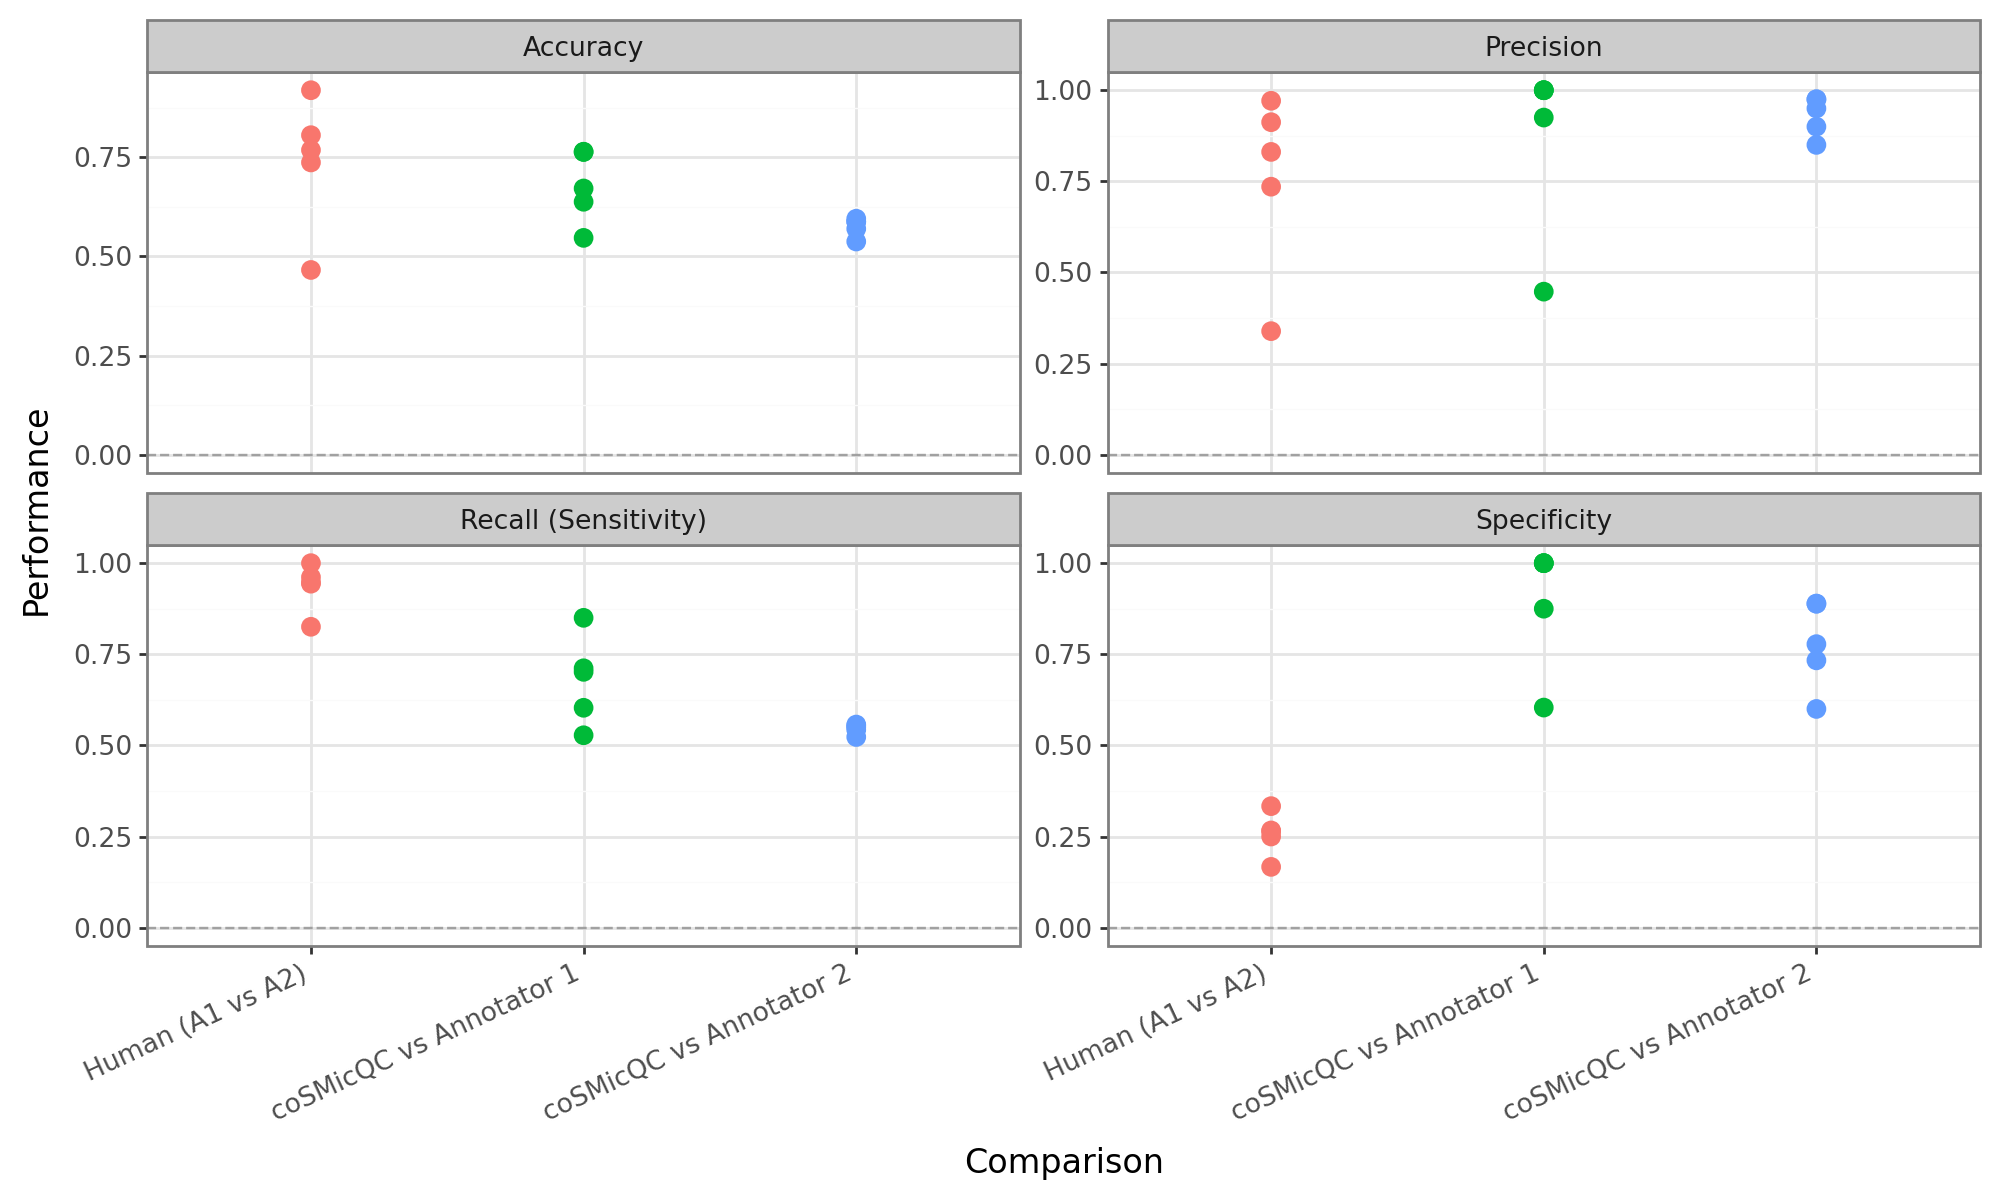

In [14]:
# -----------------------------
# reshape to long format
# -----------------------------
plot_df = metrics_df.melt(
    id_vars=["cell_line", "comparison"],
    value_vars=[
        "accuracy",
        "precision",
        "recall",
        "specificity"
    ],
    var_name="metric",
    value_name="value"
)

# -----------------------------
# clean metric names
# -----------------------------
metric_map = {
    "accuracy": "Accuracy",
    "precision": "Precision",
    "recall": "Recall (Sensitivity)",
    "specificity": "Specificity"
}

plot_df["metric"] = plot_df["metric"].map(metric_map)

# -----------------------------
# enforce ordering
# -----------------------------
metric_order = [
    "Accuracy",
    "Precision",
    "Recall (Sensitivity)",
    "Specificity"
]

plot_df["metric"] = pd.Categorical(
    plot_df["metric"],
    categories=metric_order,
    ordered=True
)

# -----------------------------
# plot
# -----------------------------
width = 7
height = 5

set_option("figure_size", (width, height))

p = (
    ggplot(
        plot_df,
        aes(
            x="comparison",
            y="value",
            color="comparison"
        )
    )

    # metric points
    + geom_point(size=3)

    # facet by metric
    + facet_wrap("~metric", scales="free_y")

    + geom_hline(
        yintercept=0,
        linetype="dashed",
        alpha=0.3
    )

    + labs(
        x="Comparison",
        y="Performance"
    )

    + theme_bw(base_size=12)
    + theme(
        axis_text_x=element_text(rotation=25, hjust=1),
        figure_size=(10, 6),
        legend_position="none"
    )
)

p.save(
    "./figures/model_performance_versus_annotators.png",
    dpi=600,
    width=width,
    height=height,
    verbose=False,
)

p.show()

## Confusion matrix

In [41]:
# --- long-format confusion matrix per cell line + annotator ---
cm_df_cell_line = (
    manual_eval_df
    .groupby([
        "annotator",
        "Metadata_cell_line",
        "failed_qc",
        "manual_segmentation_is_bad"
    ])
    .size()
    .reset_index(name="count")
)

# -----------------------------
# FORCE FULL 2x2 GRID PER FACET
# -----------------------------
full_index = pd.DataFrame(
    itertools.product(
        cm_df_cell_line["annotator"].unique(),
        cm_df_cell_line["Metadata_cell_line"].unique(),
        [0, 1],
        [0, 1],
    ),
    columns=[
        "annotator",
        "Metadata_cell_line",
        "failed_qc",
        "manual_segmentation_is_bad",
    ],
)

cm_df_cell_line = full_index.merge(
    cm_df_cell_line,
    on=[
        "annotator",
        "Metadata_cell_line",
        "failed_qc",
        "manual_segmentation_is_bad",
    ],
    how="left",
)

cm_df_cell_line["count"] = cm_df_cell_line["count"].fillna(0)

# -----------------------------
# Compute column normalized proportions
# -----------------------------
cm_df_cell_line["col_sum"] = cm_df_cell_line.groupby(
    ["annotator", "Metadata_cell_line", "manual_segmentation_is_bad"]
)["count"].transform("sum")

cm_df_cell_line["proportion"] = (
    cm_df_cell_line["count"] / cm_df_cell_line["col_sum"]
)

cm_df_cell_line["proportion"] = cm_df_cell_line["proportion"].fillna(0)

# -----------------------------
# pretty labels
# -----------------------------
cm_df_cell_line["coSMicQC failed_qc"] = cm_df_cell_line["failed_qc"].map(
    {1: "Failed QC", 0: "Passed QC"}
)

cm_df_cell_line["Manual bad segmentation"] = cm_df_cell_line[
    "manual_segmentation_is_bad"
].map(
    {1: "Failed QC", 0: "Passed QC"}
)

cm_df_cell_line["count"] = cm_df_cell_line["count"].fillna(0).astype(int)

cm_df_cell_line.head()

,annotator,Metadata_cell_line,failed_qc,manual_segmentation_is_bad,count,col_sum,proportion,coSMicQC failed_qc,Manual bad segmentation
0,Annotator 1,CHLA-10,0,0,21,24.0,0.875000,Passed QC,Passed QC
1,Annotator 1,CHLA-10,0,1,15,52.0,0.288462,Passed QC,Failed QC
2,Annotator 1,CHLA-10,1,0,3,24.0,0.125000,Failed QC,Passed QC
3,Annotator 1,CHLA-10,1,1,37,52.0,0.711538,Failed QC,Failed QC
4,Annotator 1,CHLA-113,0,0,3,3.0,1.000000,Passed QC,Passed QC


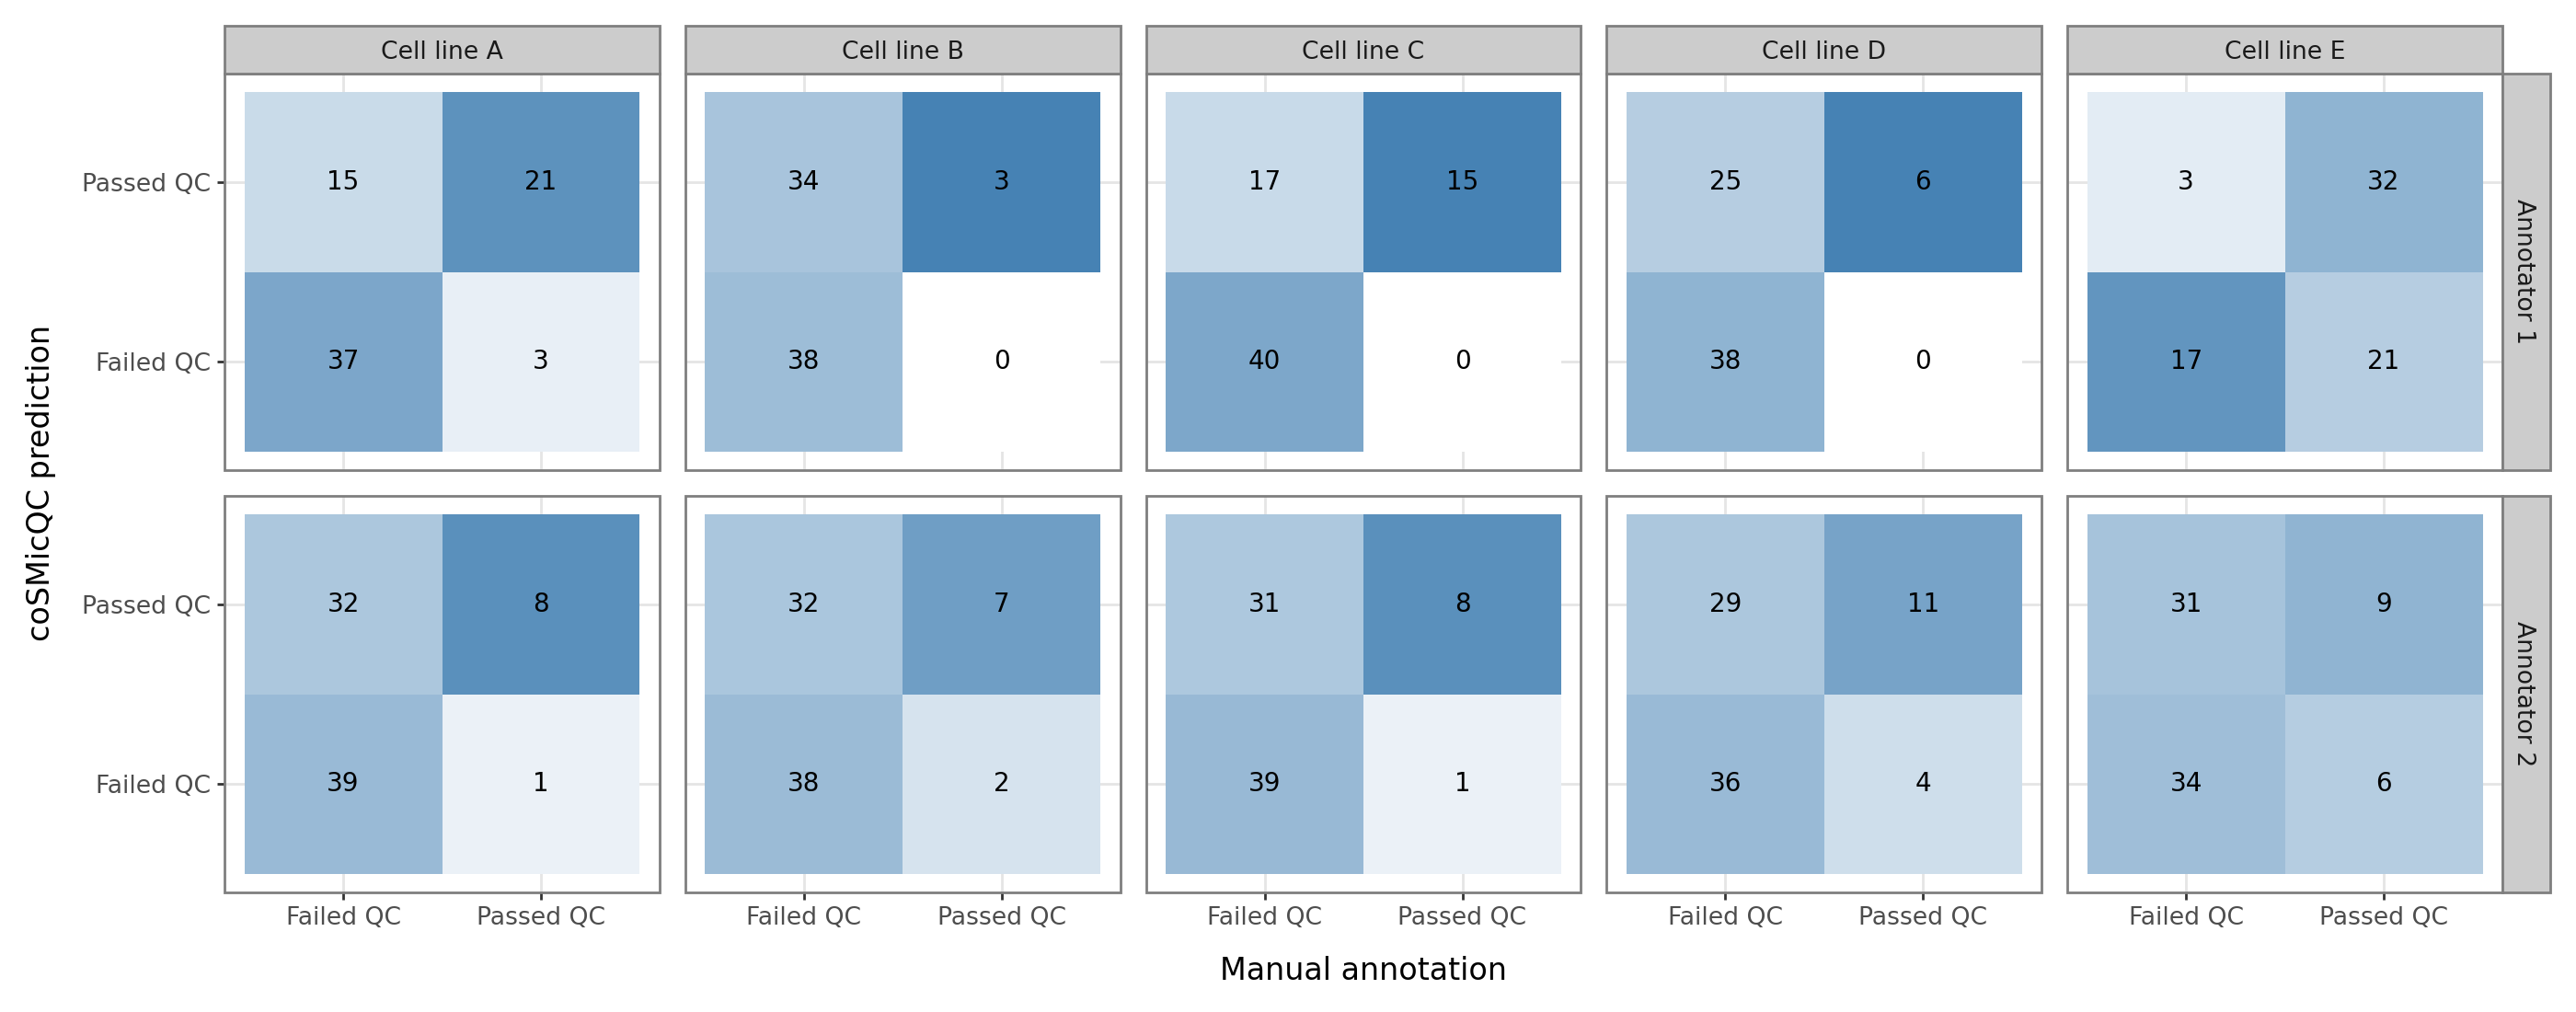

In [45]:
# -----------------------------
# Cell line mapping (blinded names)
# -----------------------------
cell_line_map = {
    "CHLA-10": "Cell line A",
    "CHLA-113": "Cell line B",
    "CHLA-218": "Cell line C",
    "CHLA-25": "Cell line D",
    "U2-OS": "Cell line E",
}

cm_df_cell_line["Cell_line"] = cm_df_cell_line["Metadata_cell_line"].map(cell_line_map)

# Set the figure size
width = 14
height = 5.5
set_option("figure_size", (width, height))

p_cm = (
    ggplot(cm_df_cell_line)
    + aes(
        x="Manual bad segmentation",
        y="coSMicQC failed_qc",
        fill="proportion",
    )
    + geom_tile()
    + geom_text(aes(label="count"), size=10)
    + facet_grid("annotator ~ Cell_line")
    + scale_fill_gradient(low="white", high="steelblue", limits=(0, 1))
    + labs(
        x="Manual annotation",
        y="coSMicQC prediction",
        fill="Column-normalized\nproportion",
    )
    + theme_bw(base_size=12)
    + theme(legend_position="none")
)

p_cm.save(
    "./figures/manual_annotation_confusion_matrix_facet_celltype.png",
    dpi=600,
    width=width,
    height=height,
    verbose=False,
)
p_cm.show()

In [46]:
# -----------------------------
# sample_row_id uniquely identifies a sample — use it directly
# -----------------------------
id_col = "sample_row_id"

annotators = sorted(manual_eval_df["annotator"].unique())
ann1, ann2 = annotators[0], annotators[1]

# -----------------------------
# Pull sample-level metadata (should be constant across annotators for the same sample_row_id)
# -----------------------------
sample_meta = (
    manual_eval_df
    .drop_duplicates(subset=[id_col])
    [[id_col, "Metadata_cell_line", "failed_qc"]]
)

# -----------------------------
# Pivot manual_segmentation_is_bad wide by annotator, per sample
# -----------------------------
wide_df = manual_eval_df.pivot_table(
    index=id_col,
    columns="annotator",
    values="manual_segmentation_is_bad",
    aggfunc="first",
).reset_index()

wide_df = wide_df.rename(columns={ann1: "annotator_1_seg", ann2: "annotator_2_seg"})
wide_df = wide_df.dropna(subset=["annotator_1_seg", "annotator_2_seg"])

# merge back in cell line + failed_qc
wide_df = wide_df.merge(sample_meta, on=id_col, how="left")
wide_df.head()

,sample_row_id,annotator_1_seg,annotator_2_seg,Metadata_cell_line,failed_qc
0,1,1.0,1.0,CHLA-10,0
1,2,0.0,0.0,CHLA-10,0
2,3,1.0,1.0,CHLA-10,0
3,4,0.0,1.0,CHLA-10,0
4,5,1.0,1.0,CHLA-10,0


In [47]:
# -----------------------------
# long-format confusion matrix: per cell line + failed_qc,
# annotator 1 (y) vs annotator 2 (x) segmentation labels
# -----------------------------
cm_df_cell_line = (
    wide_df
    .groupby(["Metadata_cell_line", "failed_qc", "annotator_1_seg", "annotator_2_seg"])
    .size()
    .reset_index(name="count")
)

# -----------------------------
# FORCE FULL 2x2 GRID PER FACET
# -----------------------------
full_index = pd.DataFrame(
    itertools.product(
        cm_df_cell_line["Metadata_cell_line"].unique(),
        [0, 1],  # failed_qc
        [0, 1],  # annotator_1_seg
        [0, 1],  # annotator_2_seg
    ),
    columns=["Metadata_cell_line", "failed_qc", "annotator_1_seg", "annotator_2_seg"],
)

cm_df_cell_line = full_index.merge(
    cm_df_cell_line,
    on=["Metadata_cell_line", "failed_qc", "annotator_1_seg", "annotator_2_seg"],
    how="left",
)
cm_df_cell_line["count"] = cm_df_cell_line["count"].fillna(0)

# -----------------------------
# pretty labels
# -----------------------------
label_map = {1: "Failed QC", 0: "Passed QC"}
cm_df_cell_line["coSMicQC failed_qc"] = cm_df_cell_line["failed_qc"].map(label_map)
cm_df_cell_line["Annotator 1"] = cm_df_cell_line["annotator_1_seg"].map(label_map)
cm_df_cell_line["Annotator 2"] = cm_df_cell_line["annotator_2_seg"].map(label_map)
cm_df_cell_line["count"] = cm_df_cell_line["count"].astype(int)

# -----------------------------
# Collapse across failed_qc so each cell line facet has one clean 2x2 grid
# -----------------------------
cm_df_cell_line_collapsed = (
    cm_df_cell_line
    .groupby(["Metadata_cell_line", "Annotator 1", "Annotator 2"])["count"]
    .sum()
    .reset_index()
)

cm_df_cell_line_collapsed["col_sum"] = cm_df_cell_line_collapsed.groupby(
    ["Metadata_cell_line", "Annotator 2"]
)["count"].transform("sum")

cm_df_cell_line_collapsed["proportion"] = (
    cm_df_cell_line_collapsed["count"] / cm_df_cell_line_collapsed["col_sum"]
).fillna(0)

cm_df_cell_line_collapsed.head()

,Metadata_cell_line,Annotator 1,Annotator 2,count,col_sum,proportion
0,CHLA-10,Failed QC,Failed QC,50,68,0.735294
1,CHLA-10,Failed QC,Passed QC,2,8,0.250000
2,CHLA-10,Passed QC,Failed QC,18,68,0.264706
3,CHLA-10,Passed QC,Passed QC,6,8,0.750000
4,CHLA-113,Failed QC,Failed QC,67,69,0.971014


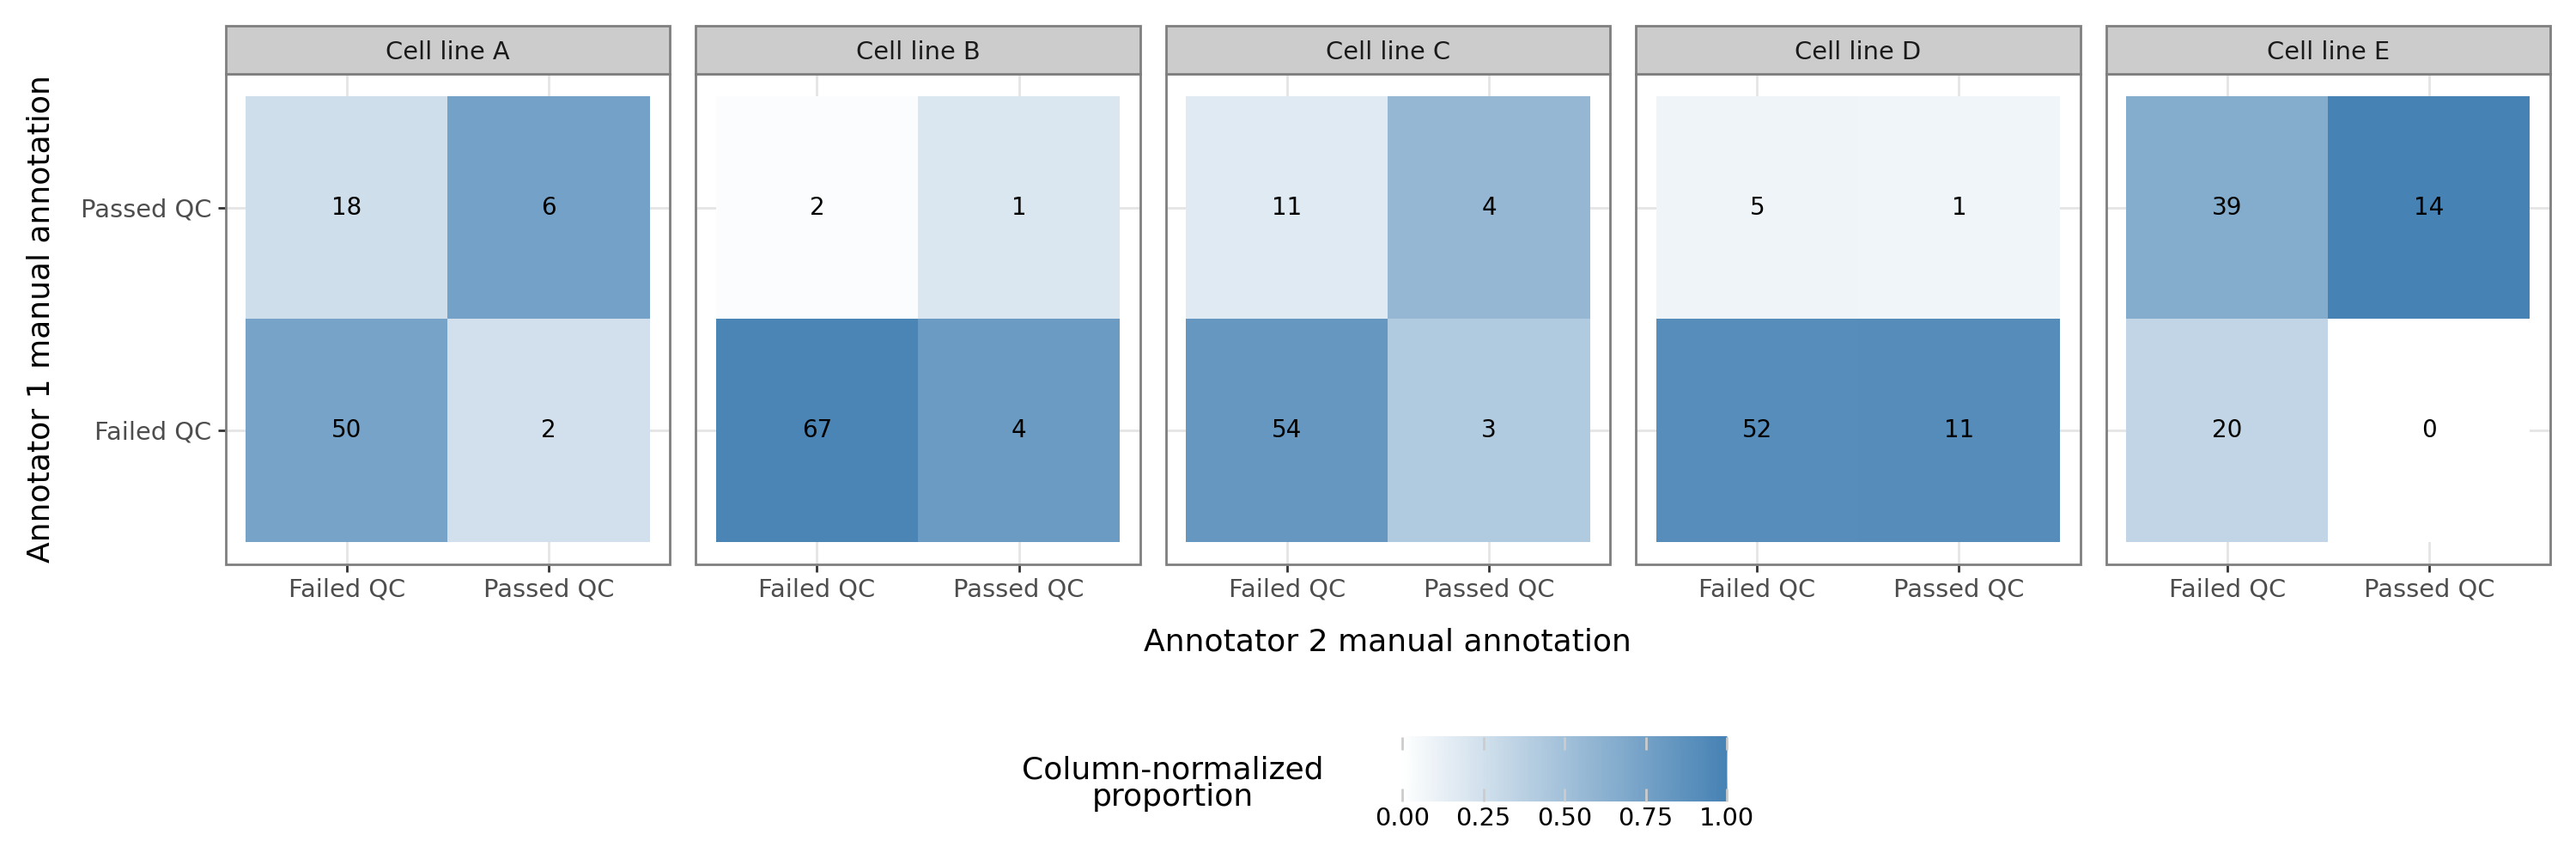

In [52]:
# -----------------------------
# Cell line mapping (blinded names)
# -----------------------------
cell_line_map = {
    "CHLA-10": "Cell line A",
    "CHLA-113": "Cell line B",
    "CHLA-218": "Cell line C",
    "CHLA-25": "Cell line D",
    "U2-OS": "Cell line E",
}

cm_df_cell_line_collapsed["Cell_line"] = cm_df_cell_line_collapsed[
    "Metadata_cell_line"
].map(cell_line_map)

width = 15
height = 5
set_option("figure_size", (width, height))

p_cm = (
    ggplot(cm_df_cell_line_collapsed)
    + aes(
        x="Annotator 2",
        y="Annotator 1",
        fill="proportion",
    )
    + geom_tile()
    + geom_text(aes(label="count"), size=10)
    + facet_wrap("~Cell_line", nrow=1)
    + scale_fill_gradient(low="white", high="steelblue", limits=(0, 1))
    + labs(
        x="Annotator 2 manual annotation",
        y="Annotator 1 manual annotation",
        fill="Column-normalized\nproportion",
    )
    + theme_bw(base_size=13)
    + theme(legend_position="bottom")
)

p_cm.save(
    "./figures/annotator_comparison_confusion_matrix_facet_celltype.png",
    dpi=600,
    width=width,
    height=height,
    verbose=False,
)
p_cm.show()

In [17]:
# Keep only good/bad annotations
agreement_df = annotations_df.loc[
    annotations_df["manual_segmentation_label"].isin(["good", "bad"])
].copy()

# One row per cell, one column per annotator
agreement_df = agreement_df.pivot(
    index="sample_row_id",
    columns="annotator",
    values="manual_segmentation_label",
)

# Keep only cells annotated by both annotators
agreement_df = agreement_df.dropna()

# Make sure exactly two annotators are present
annotators = sorted(agreement_df.columns)

if len(annotators) != 2:
    raise ValueError(
        f"Expected 2 annotators, found {len(annotators)}: {annotators}"
    )

a1, a2 = annotators

# Compute metrics
percent_agreement = (
    agreement_df[a1] == agreement_df[a2]
).mean()

kappa = cohen_kappa_score(
    agreement_df[a1],
    agreement_df[a2],
)

cm = confusion_matrix(
    agreement_df[a1],
    agreement_df[a2],
    labels=["good", "bad"],
)

print(f"Annotator 1: {a1}")
print(f"Annotator 2: {a2}")
print(f"Cells compared: {len(agreement_df):,}")
print(f"Percent agreement: {percent_agreement:.3%}")
print(f"Cohen's kappa: {kappa:.3f}")

print("\nConfusion matrix")
print(
    pd.DataFrame(
        cm,
        index=["A1_good", "A1_bad"],
        columns=["A2_good", "A2_bad"],
    )
)

Annotator 1: Annotator 1
Annotator 2: Annotator 2
Cells compared: 364
Percent agreement: 73.901%
Cohen's kappa: 0.218

Confusion matrix
         A2_good  A2_bad
A1_good       26      75
A1_bad        20     243


In [18]:
results = []

cell_lines = manual_eval_df["Metadata_cell_line"].unique()

for cl in cell_lines:

    df_cl = manual_eval_df[manual_eval_df["Metadata_cell_line"] == cl]

    # split annotators
    a1 = df_cl[df_cl["annotator"] == "Annotator 1"][
        ["sample_row_id", "manual_segmentation_is_bad", "failed_qc"]
    ]

    a2 = df_cl[df_cl["annotator"] == "Annotator 2"][
        ["sample_row_id", "manual_segmentation_is_bad", "failed_qc"]
    ]

    # -----------------------------
    # align A1 vs A2 (human baseline)
    # -----------------------------
    human = a1.merge(
        a2,
        on="sample_row_id",
        suffixes=("_a1", "_a2")
    )

    if len(human) > 1:
        kappa_a1_a2 = cohen_kappa_score(
            human["manual_segmentation_is_bad_a1"],
            human["manual_segmentation_is_bad_a2"],
        )
    else:
        kappa_a1_a2 = np.nan

    # -----------------------------
    # model vs A1
    # -----------------------------
    if len(a1) > 0:
        kappa_model_a1 = cohen_kappa_score(
            a1["failed_qc"],
            a1["manual_segmentation_is_bad"],
        )
    else:
        kappa_model_a1 = np.nan

    # -----------------------------
    # model vs A2
    # -----------------------------
    if len(a2) > 0:
        kappa_model_a2 = cohen_kappa_score(
            a2["failed_qc"],
            a2["manual_segmentation_is_bad"],
        )
    else:
        kappa_model_a2 = np.nan

    results.append({
        "cell_line": cl,
        "kappa_A1_A2": kappa_a1_a2,
        "kappa_model_A1": kappa_model_a1,
        "kappa_model_A2": kappa_model_a2,
    })

kappa_df = pd.DataFrame(results)

print("Per cell line κ:")
print(kappa_df)

print("\nMean ± SD across cell lines:")
print(
    kappa_df[
        ["kappa_A1_A2", "kappa_model_A1", "kappa_model_A2"]
    ].agg(["mean", "std"])
)

# -----------------------------
# OVERALL κ (pooled across all cell lines)
# -----------------------------
human_all = manual_eval_df.merge(
    manual_eval_df,
    on="sample_row_id",
    suffixes=("_a1", "_a2")
)

human_all = human_all[
    (human_all["annotator_a1"] == "Annotator 1") &
    (human_all["annotator_a2"] == "Annotator 2")
]

overall_kappa = cohen_kappa_score(
    human_all["manual_segmentation_is_bad_a1"],
    human_all["manual_segmentation_is_bad_a2"],
)

print("\nOverall κ (pooled across all cell lines):")
print(overall_kappa)

Per cell line κ:
  cell_line  kappa_A1_A2  kappa_model_A1  kappa_model_A2
0   CHLA-10     0.257812        0.516949        0.175000
1  CHLA-218     0.266376        0.495050        0.181877
2   CHLA-25    -0.005464        0.209078        0.175000
3  CHLA-113     0.209964        0.082073        0.130744
4     U2-OS     0.164367        0.354458        0.075000

Mean ± SD across cell lines:
      kappa_A1_A2  kappa_model_A1  kappa_model_A2
mean     0.178611        0.331522        0.147524
std      0.110731        0.186325        0.045363

Overall κ (pooled across all cell lines):
0.21793016102768226


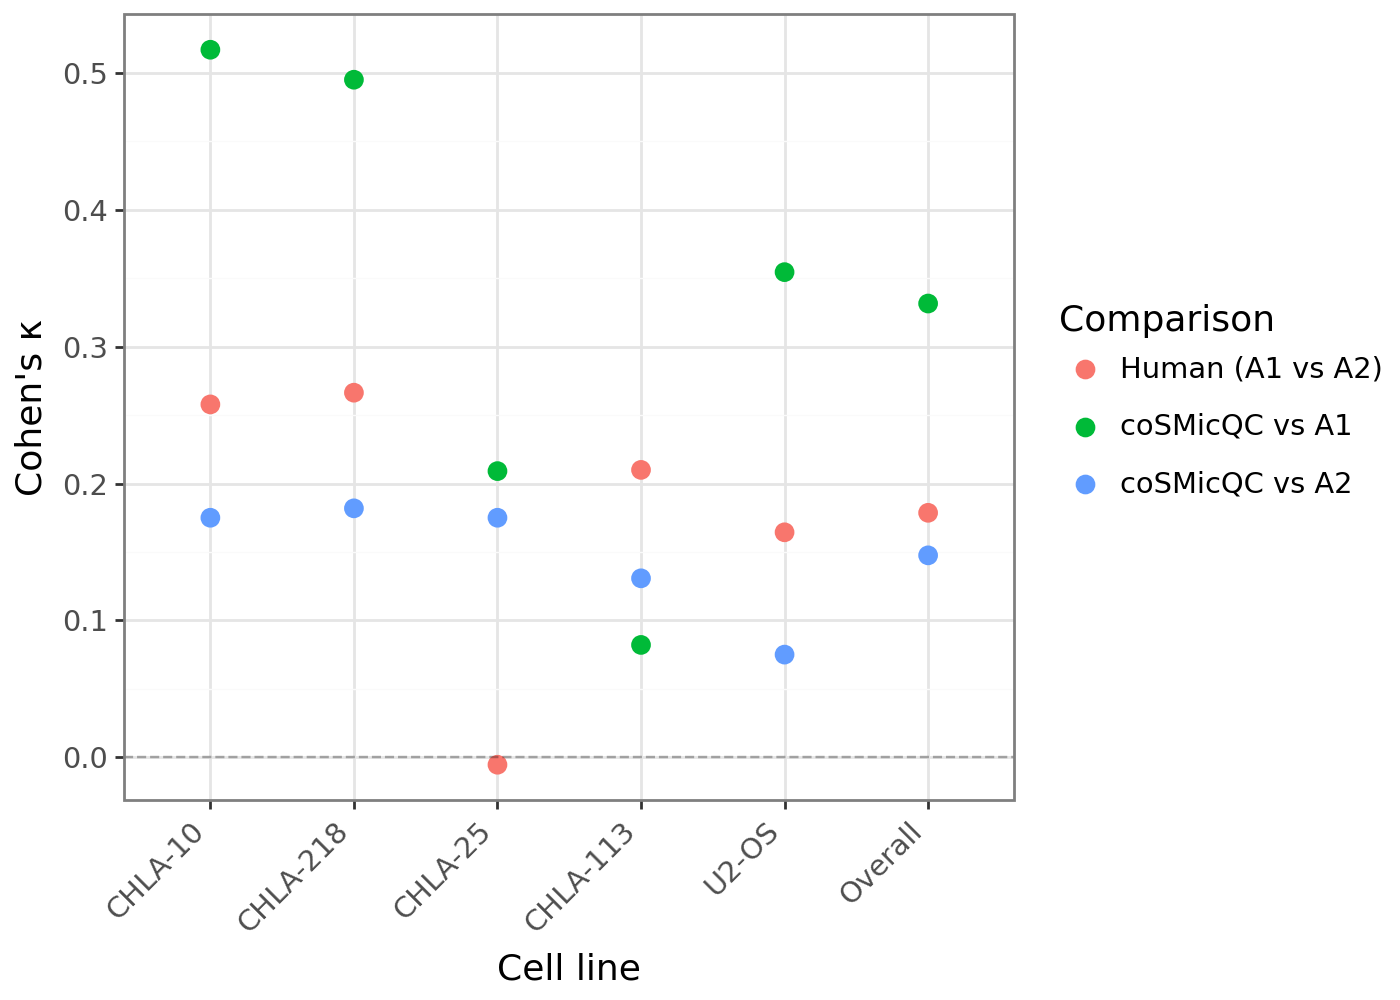

In [19]:
# -----------------------------
# reshape to long format
# -----------------------------
plot_df = kappa_df.melt(
    id_vars="cell_line",
    value_vars=["kappa_A1_A2", "kappa_model_A1", "kappa_model_A2"],
    var_name="comparison",
    value_name="kappa",
)

# -----------------------------
# label cleanup
# -----------------------------
label_map = {
    "kappa_A1_A2": "Human (A1 vs A2)",
    "kappa_model_A1": "coSMicQC vs A1",
    "kappa_model_A2": "coSMicQC vs A2",
}

plot_df["comparison"] = plot_df["comparison"].map(label_map)

# -----------------------------
# add overall mean summary row
# -----------------------------
overall = kappa_df[
    ["kappa_A1_A2", "kappa_model_A1", "kappa_model_A2"]
].mean()

overall_df = pd.DataFrame({
    "cell_line": ["Overall"] * 3,
    "comparison": [
        "Human (A1 vs A2)",
        "coSMicQC vs A1",
        "coSMicQC vs A2",
    ],
    "kappa": [
        overall["kappa_A1_A2"],
        overall["kappa_model_A1"],
        overall["kappa_model_A2"],
    ],
})

plot_df = pd.concat([plot_df, overall_df], ignore_index=True)

# -----------------------------
# enforce categorical alignment
# -----------------------------
cell_order = [*list(kappa_df["cell_line"].unique()), "Overall"]

plot_df["cell_line"] = pd.Categorical(
    plot_df["cell_line"],
    categories=cell_order,
    ordered=True
)

# -----------------------------
# plot
# -----------------------------
width = 7
height = 5
set_option("figure_size", (width, height))

p = (
    ggplot(
        plot_df,
        aes(
            x="cell_line",
            y="kappa",
            color="comparison"
        )
    )
    + geom_point(size=3)

    + geom_hline(
        yintercept=0,
        linetype="dashed",
        alpha=0.3
    )

    + labs(
        x="Cell line",
        y="Cohen's κ",
        color="Comparison",
    )

    + theme_bw(base_size=13)
    + theme(
        axis_text_x=element_text(rotation=45, hjust=1)
    )
)

p.save(
    "./figures/kappa_human_vs_model.png",
    width=width,
    height=height,
    dpi=600,
    verbose=False,
)

p.show()